In [179]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [180]:
df = pd.read_csv('../data/cleaned_bank_churn.csv')

In [181]:
df = pd.get_dummies(df, columns = ['country', 'gender'], drop_first = True)

In [182]:
X = df.drop('churn', axis = 1)
y = df['churn']

In [183]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [184]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [185]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [186]:
lr_pred = lr.predict(X_test_scaled)

In [187]:
print("accuracy:", accuracy_score(y_test, lr_pred))

print("\nclassification report:\n", classification_report(y_test, lr_pred))

accuracy: 0.7195

classification report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



In [188]:
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
print("ROC AUC Score:", lr_auc)

ROC AUC Score: 0.7822693654194197


In [189]:
rf = RandomForestClassifier(n_estimators = 200, random_state = 42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [190]:
rf_pred = rf.predict(X_test)

In [191]:
print("accuracy:", accuracy_score(y_test, rf_pred))
print("\nclassification report:\n", classification_report(y_test, rf_pred))

accuracy: 0.8705

classification report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [192]:
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("ROC AUC Score:", rf_auc)

ROC AUC Score: 0.862467955873714


In [193]:
xgb = XGBClassifier( eval_metric = 'logloss', random_state = 42)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [194]:
xgb_pred = xgb.predict(X_test)

In [195]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))

Accuracy: 0.8695



Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      1607
           1       0.72      0.55      0.63       393

    accuracy                           0.87      2000
   macro avg       0.81      0.75      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [196]:
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print("ROC AUC Score:", xgb_auc)

ROC AUC Score: 0.8502306227050548


In [197]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC_Score': [lr_auc, rf_auc, xgb_auc]
})
results

,Model,ROC_AUC_Score
0,Logistic Regression,0.782269
1,Random Forest,0.862468
2,XGBoost,0.850231


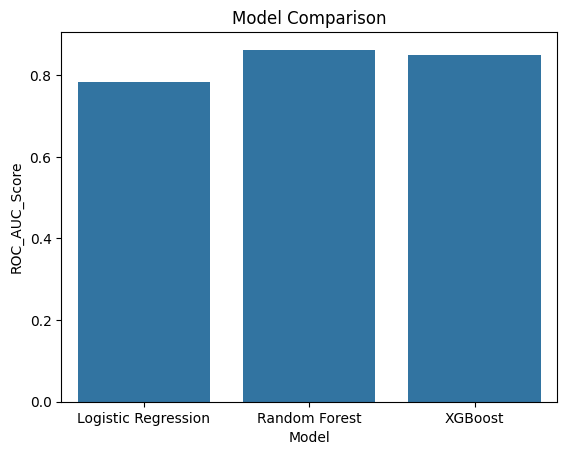

In [198]:
plt.Figure(figsize = (8, 5))

sns.barplot(x = 'Model', y = 'ROC_AUC_Score', data = results)
plt.title("Model Comparison")
plt.show()

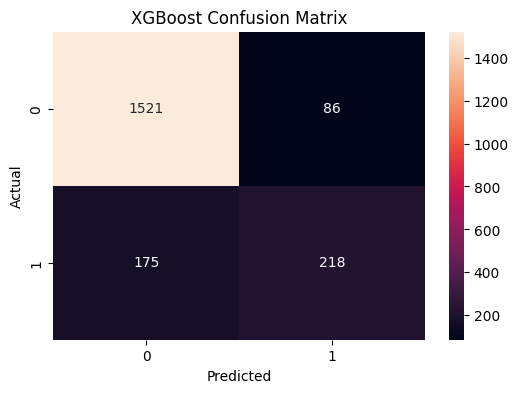

In [199]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()


In [200]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
4,products_number,0.283419
6,active_member,0.231556
1,age,0.117766
8,country_Germany,0.085248
3,balance,0.056116
10,gender_Male,0.051364
9,country_Spain,0.040662
0,credit_score,0.035073
7,estimated_salary,0.034945
2,tenure,0.033138


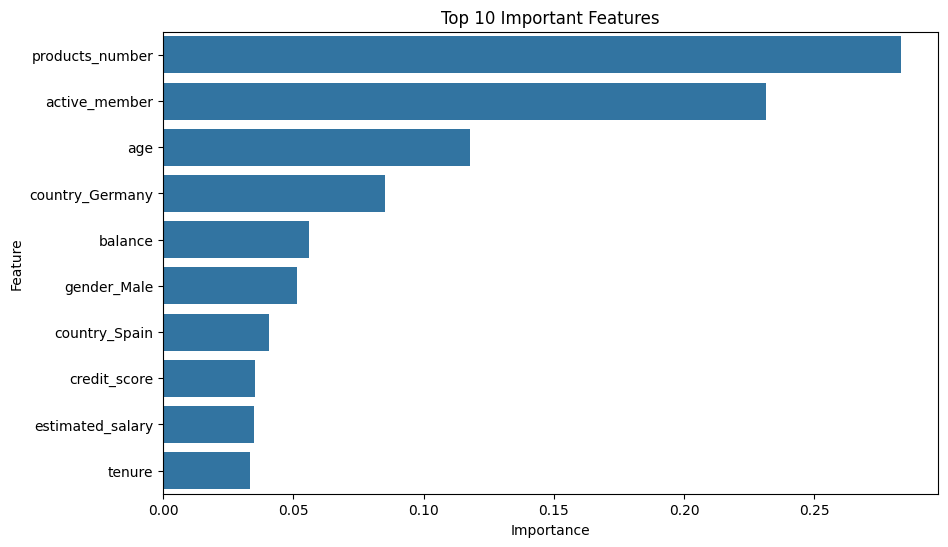

In [201]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

In [202]:
import pickle

pickle.dump(
    xgb,
    open("../models/xgboost_model.pkl", "wb")
)

In [203]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, lr_pred))

[[1159  448]
 [ 113  280]]


In [204]:
print(y.value_counts())
print(y.value_counts(normalize=True))

churn
0    7963
1    2037
Name: count, dtype: int64
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [205]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))


              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



In [207]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC_Score': [lr_auc, rf_auc, xgb_auc]
})
results

,Model,ROC_AUC_Score
0,Logistic Regression,0.782269
1,Random Forest,0.862468
2,XGBoost,0.850231


In [206]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

metrics_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value":[
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        roc_auc_score(
            y_test,
            lr.predict_proba(X_test)[:,1]
        )
    ]
})

metrics_df

c:\Users\Singh\Dev\Customer Churn Analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,Metric,Value
0,Accuracy,0.719500
1,Precision,0.384615
2,Recall,0.712468
3,F1 Score,0.499554
4,ROC-AUC,0.502458


In [2]:
# Improved churn model: stratified split, imbalance handling, and threshold tuning
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from scipy.stats import randint, uniform

df = pd.read_csv('../data/cleaned_bank_churn.csv')
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        tree_method='hist',
        scale_pos_weight=scale_pos_weight
    ),
    param_distributions={
        'n_estimators': randint(150, 500),
        'max_depth': randint(3, 8),
        'learning_rate': uniform(0.02, 0.18),
        'subsample': uniform(0.7, 0.3),
        'colsample_bytree': uniform(0.7, 0.3),
        'min_child_weight': randint(1, 8),
        'gamma': uniform(0.0, 0.3)
    },
    n_iter=20,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

best_xgb.fit(X_fit, y_fit)
val_proba = best_xgb.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_threshold = thresholds[f1_scores[:-1].argmax()] if len(thresholds) else 0.5

test_proba = best_xgb.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

improved_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'PR-AUC'],
    'Value': [
        accuracy_score(y_test, test_pred),
        precision_score(y_test, test_pred, zero_division=0),
        recall_score(y_test, test_pred, zero_division=0),
        f1_score(y_test, test_pred, zero_division=0),
        roc_auc_score(y_test, test_proba),
        average_precision_score(y_test, test_proba)
    ]
})

print('Best parameters:', xgb_search.best_params_)
print('Best validation threshold:', best_threshold)
improved_metrics


Best parameters: {'colsample_bytree': np.float64(0.9266653415629146), 'gamma': np.float64(0.06863944964748674), 'learning_rate': np.float64(0.033856383769182735), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 235, 'subsample': np.float64(0.9641403517045772)}
Best validation threshold: 0.6325709


,Metric,Value
0,Accuracy,0.851000
1,Precision,0.637280
2,Recall,0.621622
3,F1 Score,0.629353
4,ROC-AUC,0.866713
5,PR-AUC,0.713317


In [ ]:
improved_metrics.to_csv('../data/model_metrics.csv', index=False)
print('Updated ../data/model_metrics.csv')